# Replicating Sugihara et al. (2012) — *Detecting Causality in Complex Ecosystems*
### All figures related to our specific case: Convergent Cross Mapping on Sardine / Anchovy / SST data

**Reference:** Sugihara, G., May, R., Ye, H., Hsieh, C.-H., Deyle, E., Fogarty, M., & Munch, S. (2012).
Detecting causality in complex ecosystems. *Science*, 338(6106), 496–500.
DOI: [10.1126/science.1227079](https://doi.org/10.1126/science.1227079)

---

### Background

Classical correlation cannot reliably detect causation in nonlinear, coupled ecological systems
because variables can appear correlated or uncorrelated depending on system state (*mirage
correlations*). **Convergent Cross Mapping (CCM)** sidesteps this by exploiting Takens'
embedding theorem: if variable Y causally influences variable X, then Y's signature is
encoded in X's attractor manifold. CCM tests this by asking whether the shadow manifold
built from X can predict Y and whether that predictive skill *improves
as more data are used* (convergence).

**The sardine-anchovy problem** (paper Fig. 5) is a landmark test case. Pacific sardine
(*Sardinops sagax*) and northern anchovy (*Engraulis mordax*) show alternating dominance
off California. Competing hypotheses attribute this either to direct competition between
species or to both species responding independently to sea-surface temperature (SST).
CCM settles the debate.

---

## Imports And Helper Functions

In [13]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from scipy.stats import pearsonr
from scipy.optimize import curve_fit, OptimizeWarning
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import MultipleLocator
import warnings

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### Explanation of Core Algorithms and Helper Functions

The table below describes the consolidated, optimized mathematical functions used throughout this notebook to replicate the findings of Sugihara et al. (2012).

| Function Name | Purpose | Mathematical/Algorithmic Inputs | Key Outputs | Academic Relevance |
| :--- | :--- | :--- | :--- | :--- |
| `coupled_logistic` | Simulates a deterministic 2-species chaotic system. | Initial conditions ($x_1, y_1$), growth rates ($r_x, r_y$), coupling strengths ($\beta_{xy}, \beta_{yx}$), and time horizons ($N$). | Two 1D arrays representing interacting population time series ($X$ and $Y$). | Used to generate synthetic data for verifying CCM behavior under controlled causal regimes (e.g., replicating **Figures 3 and 4**). |
| `embed` | Reconstructs a multidimensional state space from a single observed timeline. | 1D time series ($ts$), embedding dimension ($E$), and time lag ($\tau$). | A 2D array of dimension $(N \times E)$ representing the coordinate-shifted "shadow manifold" ($M_X$ or $M_Y$). | Implements **Takens’ Embedding Theorem**, proving that a single variable's history can track the topological state of the whole system. |
| `ccm_smooth` | Quantifies the causal influence of one variable on another by testing manifold cross-reconstruction convergence. | Target time series ($X_{raw}, Y_{raw}$), embedding dimensions ($E, \tau$), library length array ($L_{range}$), and bootstrap sample size ($num\_samples$). | Arrays of evaluated library sizes ($L$) and corresponding cross-map skills (Pearson correlation coefficient, $\rho$). | Calculates the core **Convergent Cross Mapping** metric. Convergence (increasing $\rho$ with larger $L$) explicitly separates true causality from mirage correlations (**Figure 5**). |

---

In [31]:
# Helper Functions for Convergent Cross Mapping (CCM)

def coupled_logistic(x1, y1, rx, ry, bxy, byx, N):
    """
    Generates time series data from a coupled 2-species logistic map.
    Used to replicate the theoretical examples in Sugihara et al. (2012).
    """
    X = np.zeros(N)
    Y = np.zeros(N)
    X[0], Y[0] = x1, y1
    for t in range(1, N):
        X[t] = X[t-1] * (rx - rx*X[t-1] - bxy*Y[t-1])
        Y[t] = Y[t-1] * (ry - ry*Y[t-1] - byx*X[t-1])
    return X, Y

def embed(ts, E, tau=1):
    """
    Generates a time-delay embedded shadow manifold from a 1D time series.
    """
    ts = np.array(ts)
    N = len(ts)
    embedded = np.full((N, E), np.nan)
    for i in range(E):
        shift = i * tau
        if shift == 0:
            embedded[:, i] = ts
        else:
            embedded[shift:, i] = ts[:-shift]
    return embedded
    
def ccm_smooth(X_raw, Y_raw, E, tau=1, L_range=None, num_samples=50):
    """
    Calculates the cross-map skill (Pearson rho) of estimating Y from the historical 
    record of X. Optimized using scipy's cKDTree for fast nearest-neighbor lookups.
    """
    np.random.seed(42) 
    X_raw, Y_raw = np.array(X_raw), np.array(Y_raw)
    
    # 1. Embed the state space
    X_embedded = embed(X_raw, E, tau)
    valid_mask = ~np.isnan(X_embedded).any(axis=1) & ~np.isnan(Y_raw)
    valid_indices = np.where(valid_mask)[0]
    
    rho_results = []
    
    for L in L_range:
        rho_L = []
        for _ in range(num_samples):
            # 2. Randomly sample the library manifold
            lib_indices = np.random.choice(valid_indices, size=L, replace=False)
            lib_vectors = X_embedded[lib_indices]
            
            # 3. Build a KD-Tree for fast nearest neighbor searches
            tree = cKDTree(lib_vectors)
            
            # 4. Query E+2 neighbors for all valid targets simultaneously
            targets = X_embedded[valid_indices]
            dists, inds = tree.query(targets, k=E+2)
            
            y_preds, y_actuals = [], []
            
            for i, t in enumerate(valid_indices):
                # 5. Filter out the target itself (Leave-one-out cross-validation)
                mask = (lib_indices[inds[i]] != t)
                
                # Take the top E+1 valid neighbors
                valid_nns_idx = inds[i][mask][:E+1]
                valid_dists = dists[i][mask][:E+1]
                
                if len(valid_nns_idx) < E + 1:
                    continue
                    
                # 6. Calculate exponential weights based on distance
                d1 = valid_dists[0]
                if d1 == 0:
                    weights = (valid_dists == 0).astype(float)
                else:
                    weights = np.exp(-valid_dists / d1)
                weights /= np.sum(weights)
                
                # 7. Map back to original indices to fetch actual Y targets
                nn_actual_indices = lib_indices[valid_nns_idx]
                y_pred = np.sum(weights * Y_raw[nn_actual_indices])
                
                y_preds.append(y_pred)
                y_actuals.append(Y_raw[t])
                
            # Calculate correlation between predicted and actual Y
            if len(y_preds) > 1:
                r, _ = pearsonr(y_preds, y_actuals)
                rho_L.append(r)
            else:
                rho_L.append(np.nan)
                
        # 8. Average the iterations and cap negative skill at 0
        mean_rho = np.nanmean(rho_L)
        rho_results.append(mean_rho)
        
    rho_results = np.maximum(0, rho_results)
    return np.array(L_range), rho_results


def convergence_model(L, alpha, gamma, rho_inf):
    """Exponential convergence model: ρ(L) = α · exp(−γL) + ρ∞."""
    return alpha * np.exp(-gamma * L) + rho_inf

def fit_and_report(L_range, rho_data, label, ax=None, color='steelblue'):
    """
    Fit ρ(L) = α·exp(−γL) + ρ∞ and report the asymptotic cross-map skill ρ∞.
    Plots the fit curve on `ax` when provided.
    """
    rho_data = np.asarray(rho_data)
    finite   = np.isfinite(rho_data)
    if finite.sum() < 4:
        print(f"  {label:55} | ⚠ too few finite points")
        return None
    Lf, rf = L_range[finite].astype(float), rho_data[finite]
    try:
        p0     = [rf.min() - rf.max(), 0.05, rf.max()]
        bounds = ([-np.inf, 0, 0], [np.inf, np.inf, 1.0])
        popt, _ = curve_fit(convergence_model, Lf, rf,
                            p0=p0, bounds=bounds, maxfev=10_000)
        alpha, gamma, rho_inf = popt
        if gamma < 1e-4 or abs(alpha) < 1e-4:
            verdict = "➡  flat / no convergence"
        else:
            verdict = f"ρ∞ = {rho_inf:.3f}   (γ = {gamma:.4f})"
        print(f"  {label:55} | {verdict}")
        if ax is not None:
            L_ext = np.linspace(Lf[0], Lf[-1] * 1.5, 300)
            ax.plot(L_ext, convergence_model(L_ext, *popt),
                    '--', color=color, lw=1.5, label=f'fit  ρ∞={rho_inf:.3f}')
        return rho_inf
    except RuntimeError:
        print(f"  {label:55} | fit did not converge")
        return None

## Figure 3A

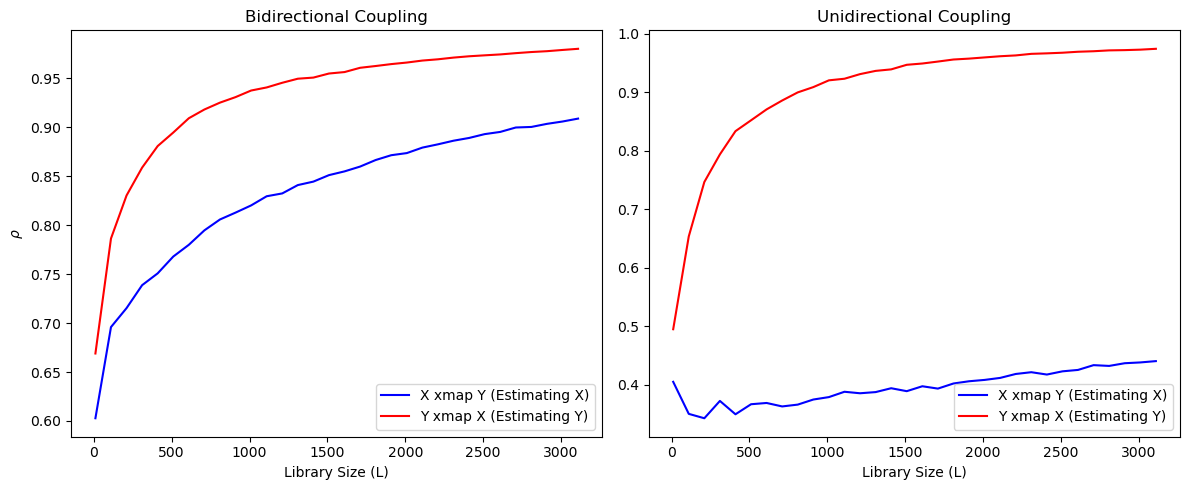

In [15]:
# Convergent cross mapping Figure 3A
N_data = 3500
rx, ry = 3.65, 3.77
L_range_sim = np.arange(10, 3200, 100)

# 1. Bidirectional Coupling 
bxy_bi, byx_bi = 0.02, 0.1
X_bi, Y_bi = coupled_logistic(0.2, 0.4, rx, ry, bxy_bi, byx_bi, N_data)
_, rho_X_bi = ccm_smooth(X_bi, Y_bi, E=2, tau=1, L_range=L_range_sim, num_samples=10)
_, rho_Y_bi = ccm_smooth(Y_bi, X_bi, E=2, tau=1, L_range=L_range_sim, num_samples=10)

# 2. Unidirectional Coupling (Y has no effect on X)
bxy_uni, byx_uni = 0.0, 0.1
X_uni, Y_uni = coupled_logistic(0.2, 0.4, rx, ry, bxy_uni, byx_uni, N_data)
_, rho_X_uni = ccm_smooth(X_uni, Y_uni, E=2, tau=1, L_range=L_range_sim, num_samples=10)
_, rho_Y_uni = ccm_smooth(Y_uni, X_uni, E=2, tau=1, L_range=L_range_sim, num_samples=10)

# Plotting Fig 3A & 3B Equivalent
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(L_range_sim, rho_X_bi, 'b-', label='X xmap Y (Estimating X)')
axes[0].plot(L_range_sim, rho_Y_bi, 'r-', label='Y xmap X (Estimating Y)')
axes[0].set_title('Bidirectional Coupling')
axes[0].set_xlabel('Library Size (L)')
axes[0].set_ylabel(r'$\rho$')
axes[0].legend()

axes[1].plot(L_range_sim, rho_X_uni, 'b-', label='X xmap Y (Estimating X)')
axes[1].plot(L_range_sim, rho_Y_uni, 'r-', label='Y xmap X (Estimating Y)')
axes[1].set_title('Unidirectional Coupling')
axes[1].set_xlabel('Library Size (L)')
axes[1].legend()
plt.tight_layout()
plt.show()
    

## Figure 3B

Calculating bidirectional heatmap (this may take a minute or two)...


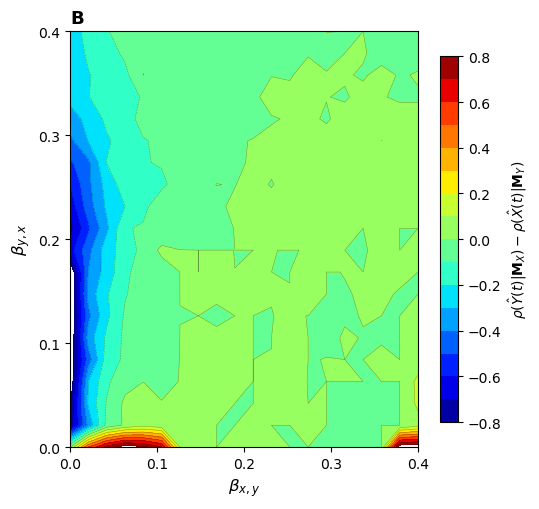

In [16]:
# Figure 3B: Heatmap of Bidirectional Coupling Asymmetry
betas = np.linspace(0, 0.4, 20)
rho_diff = np.zeros((len(betas), len(betas)))

print("Calculating bidirectional heatmap (this may take a minute or two)...")
for i, b_yx in enumerate(betas):
    for j, b_xy in enumerate(betas):
        # 1. Generate data (Generate 800 points, drop first 200 for warmup)
        X_full, Y_full = coupled_logistic(x1=0.2, y1=0.4, rx=3.8, ry=3.5, 
                                          bxy=b_xy, byx=b_yx, N=800)
        X, Y = X_full[200:], Y_full[200:]
        
        # 2. Calculate CCM in both directions at L=400
        # We drop num_samples to 5 to drastically speed up the 20x20 grid computation
        _, rho_Y_from_MX = ccm_smooth(X, Y, E=3, tau=1, L_range=[400], num_samples=5)
        _, rho_X_from_MY = ccm_smooth(Y, X, E=3, tau=1, L_range=[400], num_samples=5)
        
        # 3. Store the difference
        rho_diff[i, j] = rho_Y_from_MX[0] - rho_X_from_MY[0]

# 4. Plotting
fig, ax = plt.subplots(figsize=(5.5, 5.2))
B_X, B_Y = np.meshgrid(betas, betas)
lvls = np.linspace(-0.8, 0.8, 17)

# Swapped to 'seismic' to perfectly match the Science 2012 colormap
cf = ax.contourf(B_X, B_Y, rho_diff, levels=lvls, cmap='jet')
ax.contour(B_X, B_Y, rho_diff, levels=lvls, colors='k', linewidths=0.35, alpha=0.4)

cb = plt.colorbar(cf, ax=ax, shrink=0.88)
cb.set_label(r'$\rho(\hat{Y}(t)|\mathbf{M}_X) - \rho(\hat{X}(t)|\mathbf{M}_Y)$', fontsize=10)
cb.ax.yaxis.set_major_locator(MultipleLocator(0.2))

ax.set_xlabel(r'$\beta_{x,y}$', fontsize=12)
ax.set_ylabel(r'$\beta_{y,x}$', fontsize=12)
ax.set_xlim(0, 0.4)
ax.set_ylim(0, 0.4)
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.set_title('B', fontsize=13, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()

## Figure 3C & D

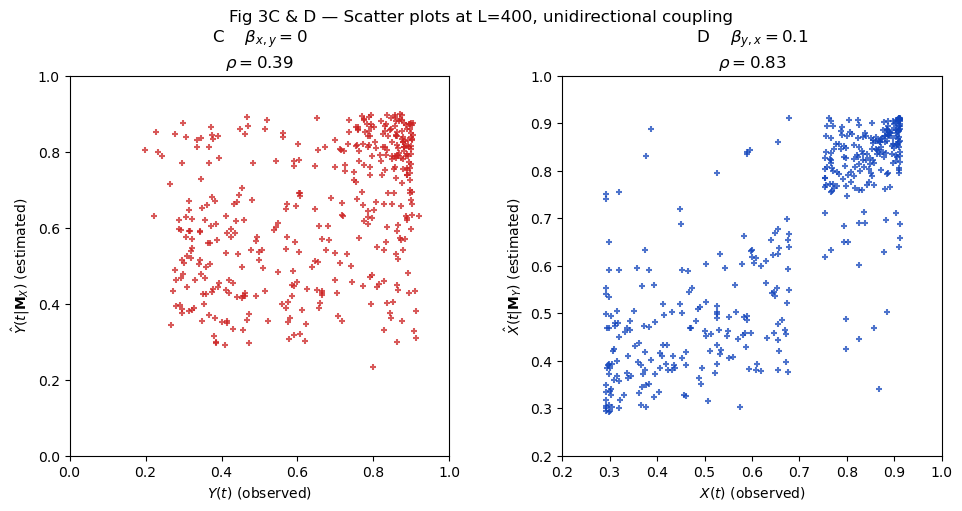

In [17]:
# Figure 3C & 3D: Scatter Plots of Cross-Map Estimates (L=400)

def ccm_predict(X_source, Y_target, E, tau=1):
    """
    Returns the actual vs. predicted values of Y_target reconstructed from the M_X manifold.
    Used specifically to generate the scatter plots in Fig 3C and 3D.
    """
    M_source = embed(X_source, E, tau)
    
    # Filter valid rows
    valid_mask = ~np.isnan(M_source).any(axis=1)
    valid_idx = np.where(valid_mask)[0]
    M_valid, Y_valid = M_source[valid_idx], Y_target[valid_idx]
    
    tree = cKDTree(M_valid)
    dists, inds = tree.query(M_valid, k=E+2)
    
    y_preds = []
    for i in range(len(valid_idx)):
        # Leave-one-out cross validation
        mask = (inds[i] != i) 
        nns, nns_dists = inds[i][mask][:E+1], dists[i][mask][:E+1]
        
        # Exponential weighting
        d1 = nns_dists[0]
        weights = (nns_dists == 0).astype(float) if d1 == 0 else np.exp(-nns_dists / d1)
        weights /= np.sum(weights)
        
        y_preds.append(np.sum(weights * Y_valid[nns]))
        
    return Y_valid, np.array(y_preds)

# Generate L=400 points of the unidirectional system (X drives Y, Y does not drive X)
np.random.seed(42)
X_s, Y_s = coupled_logistic(0.2, 0.4, rx=3.65, ry=3.77, bxy=0.0, byx=0.1, N=400)

# Get Predictions
# Panel C: Try to predict Y from X's history (Should FAIL because Y doesn't drive X)
Y_obs_C, Y_pred_C = ccm_predict(X_s, Y_s, E=2, tau=1)
rho_C, _ = pearsonr(Y_obs_C, Y_pred_C)

# Panel D: Try to predict X from Y's history (Should SUCCEED because X drives Y)
X_obs_D, X_pred_D = ccm_predict(Y_s, X_s, E=2, tau=1)
rho_D, _ = pearsonr(X_obs_D, X_pred_D)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Panel C — Diffuse red cloud (Cross-mapping FAILS)
axes[0].scatter(Y_obs_C, Y_pred_C, color='#CC2222', alpha=0.75, s=22, marker='+')
axes[0].set(xlabel='$Y(t)$ (observed)', ylabel=r'$\hat{Y}(t|\mathbf{M}_X)$ (estimated)', 
            title=f'C    $\\beta_{{x,y}} = 0$\n$\\rho = {rho_C:.2f}$',
            xlim=(0, 1), ylim=(0, 1), aspect='equal')

# Panel D — Blue diagonal (Cross-mapping SUCCEEDS)
axes[1].scatter(X_obs_D, X_pred_D, color='#1144BB', alpha=0.75, s=22, marker='+')
axes[1].set(xlabel='$X(t)$ (observed)', ylabel=r'$\hat{X}(t|\mathbf{M}_Y)$ (estimated)', 
            title=f'D    $\\beta_{{y,x}} = 0.1$\n$\\rho = {rho_D:.2f}$',
            xlim=(0.2, 1), ylim=(0.2, 1), aspect='equal')

plt.suptitle('Fig 3C & D — Scatter plots at L=400, unidirectional coupling', fontsize=12)
plt.tight_layout()
plt.show()

## Figure E 

Calculating 3D surface (this may take a minute)...


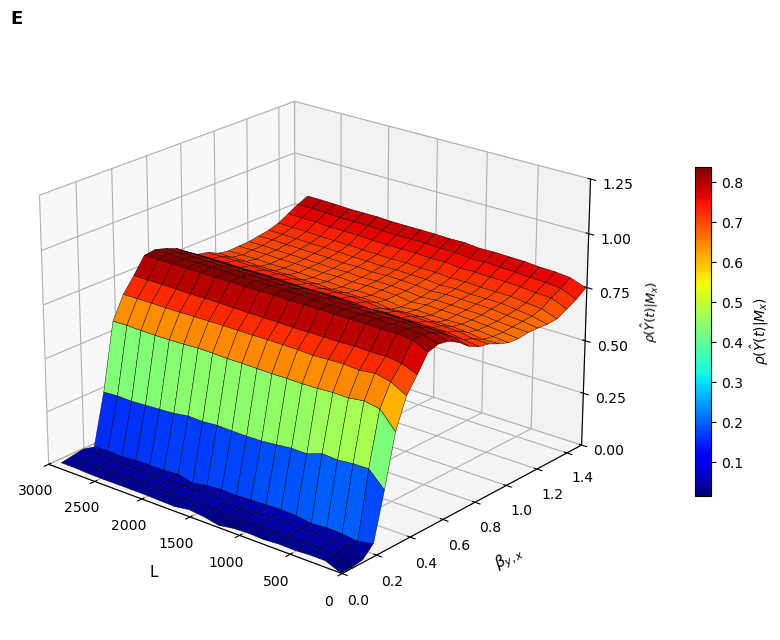

In [18]:
# Figure 3E: 3D Surface Plot of Cross-Map Skill
bxy_fixed = 0.0          # Unidirectional coupling (Y does not affect X)
rx, ry = 3.8, 3.5        # Standard chaotic growth rates
L_vals = np.arange(10, 3001, 150)   
beta_yx_vals = np.linspace(0, 1.5, 25)

rho_E = np.zeros((len(L_vals), len(beta_yx_vals)))

print("Calculating 3D surface (this may take a minute)...")
for j, byx in enumerate(beta_yx_vals):
    # 1. Generate data (Generate 3500 points, drop the first 500 to account for warmup)
    X_full, Y_full = coupled_logistic(x1=0.4, y1=0.2, rx=rx, ry=ry, bxy=bxy_fixed, byx=byx, N=3500)
    X, Y = X_full[500:], Y_full[500:] 
    
    # 2. Vectorized CCM computation 
    # (Predicting Y from M_X. We use num_samples=10 to speed up 3D grid rendering)
    _, rho_column = ccm_smooth(X, Y, E=3, tau=1, L_range=L_vals, num_samples=10)
    rho_E[:, j] = rho_column

# 3. Create the 3D Plot
BV, LV = np.meshgrid(beta_yx_vals, L_vals)

fig = plt.figure(figsize=(9, 6.5))
ax3d = fig.add_subplot(111, projection='3d')

surf = ax3d.plot_surface(LV, BV, rho_E, cmap='jet', edgecolor='k', 
                         linewidth=0.3, antialiased=True)

cbar = fig.colorbar(surf, ax=ax3d, shrink=0.55, pad=0.1)
cbar.set_label(r'$\rho(\hat{Y}(t)|M_x)$', fontsize=10)
cbar.ax.yaxis.set_major_locator(MultipleLocator(0.1))

ax3d.set_xlabel('L', fontsize=11, labelpad=10)
ax3d.set_ylabel(r'$\beta_{y,x}$', fontsize=11, labelpad=10)
ax3d.set_zlabel(r'$\rho(\hat{Y}(t)|M_x)$', fontsize=9, labelpad=6)

ax3d.set_xlim(3000, 0)   
ax3d.set_ylim(0, 1.5)
ax3d.set_zlim(0, 1.25)
ax3d.set_zticks([0, 0.25, 0.5, 0.75, 1.0, 1.25])

ax3d.view_init(elev=22, azim=-50)
ax3d.set_title('E', fontsize=13, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()

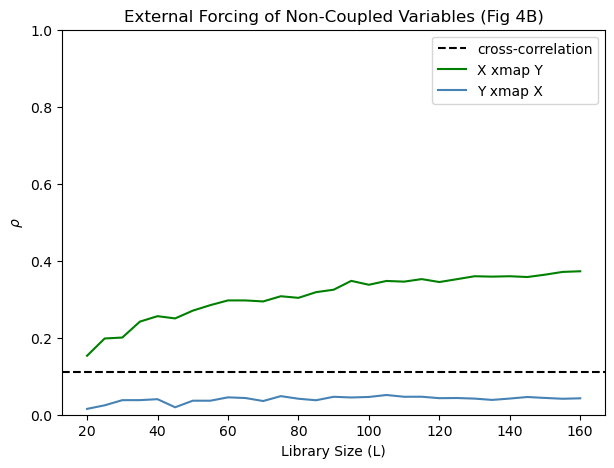

In [19]:
# Figure 4B

np.random.seed(42)
N = 1000
rx, ry, rz = 3.65, 3.77, 3.8
bxz, byz = 0.2, 0.7

Z = np.zeros(N)
X, Y = np.zeros(N), np.zeros(N)
Z[0], X[0], Y[0] = 0.5, 0.2, 0.4

for t in range(1, N):
    Z[t] = Z[t-1] * (rz - rz * Z[t-1])
    X[t] = X[t-1] * (rx - rx * X[t-1] - bxz * Z[t-1])
    Y[t] = Y[t-1] * (ry - ry * Y[t-1] - byz * Z[t-1])

L_range_ext = np.arange(20, 161, 5)
_, rho_XxmapY = ccm_smooth(X, Y, E=2, tau=1, L_range=L_range_ext, num_samples=50)
_, rho_YxmapX = ccm_smooth(Y, X, E=2, tau=1, L_range=L_range_ext, num_samples=50)

cc_value = abs(pearsonr(X, Y)[0])

fig, ax = plt.subplots(figsize=(7, 5))
ax.axhline(cc_value, color='k', linestyle='--', label='cross-correlation')
ax.plot(L_range_ext, rho_XxmapY, color='green', label='X xmap Y')
ax.plot(L_range_ext, rho_YxmapX, color='steelblue', label='Y xmap X')
ax.set_xlabel('Library Size (L)')
ax.set_ylabel(r'$\rho$')
ax.set_ylim(0, 1)
ax.set_title('External Forcing of Non-Coupled Variables (Fig 4B)')
ax.legend()
plt.show()

## APPLYING CCM ON THE DATASET 

## Imports and Loading Data

The file `sardine_anchovy_sst.RData` was converted to csv format in prior code, becoming: `sardine_anchovy_sst.vcs`.  

**Columns** (all z-score normalised in the original file):

| Column | Description |
|--------|-------------|
| `year` | 1929–2006 (78 annual observations) |
| `anchovy` | N. anchovy landings (z-scored) |
| `sardine` | Pacific sardine landings (z-scored) |
| `sio_sst` | SST at Scripps Pier, La Jolla (z-scored) — used for sardine |
| `np_sst` | SST at Newport Pier, Oregon (z-scored) — used for anchovy |

In [20]:
# Data collection
try:
    # Read the converted CSV (converted from original RData) 
    df_eco = pd.read_csv('sardine_anchovy_sst.csv') 
    
    # Preprocess: Align temporal indices and interpolate missing values
    df_eco['year'] = pd.to_datetime(df_eco['year'].astype(str), format='%Y')
    df_eco = df_eco.sort_values('year').set_index('year')
    df_eco = df_eco.interpolate(method='linear') 
    
    # Standardize units (Z-score normalization helps with distance metrics)
    df_eco_normalized = (df_eco - df_eco.mean()) / df_eco.std()
    
    # Extract specific arrays for later use
    years = df_eco.index.year.values
    sardine = df_eco_normalized['sardine'].values
    anchovy = df_eco_normalized['anchovy'].values
    sst_scripps = df_eco_normalized['sio_sst'].values
    sst_newport = df_eco_normalized['np_sst'].values
    
    print("Data loaded and preprocessed successfully.")
except FileNotFoundError:
    print("Please ensure 'sardine_anchovy_sst.csv' is in your working directory.")

Data loaded and preprocessed successfully.


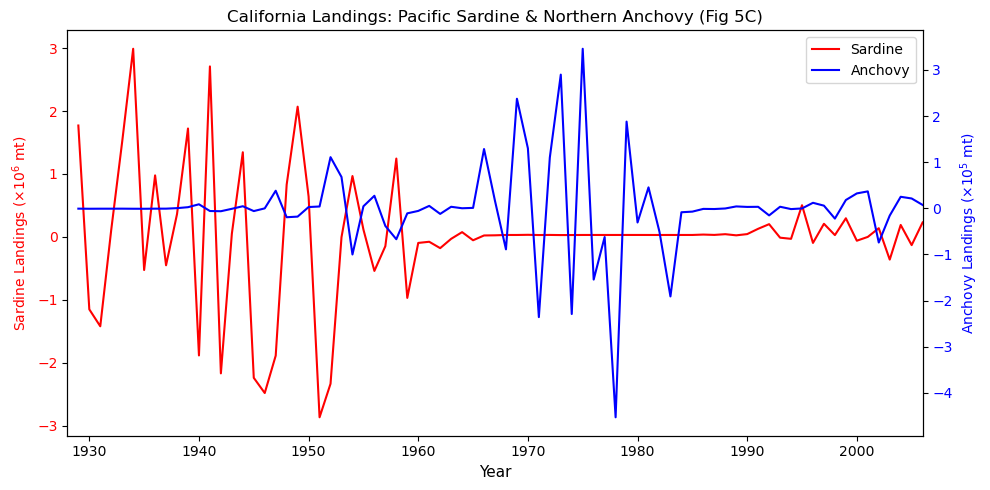

In [21]:
# Sardine-anchovy landings time graph

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel(r'Sardine Landings ($\times 10^6$ mt)', fontsize=10, color='red')
line1, = ax1.plot(years, df_eco['sardine'].values, color='red', linewidth=1.5, label='Sardine')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_xlim(1928, 2006)

ax2 = ax1.twinx()
ax2.set_ylabel(r'Anchovy Landings ($\times 10^5$ mt)', fontsize=10, color='blue')
line2, = ax2.plot(years, df_eco['anchovy'].values, color='blue', linewidth=1.5, label='Anchovy')
ax2.tick_params(axis='y', labelcolor='blue')

ax1.legend([line1, line2], ['Sardine', 'Anchovy'], loc='upper right', frameon=True)
plt.title('California Landings: Pacific Sardine & Northern Anchovy (Fig 5C)')
fig.tight_layout()
plt.show()

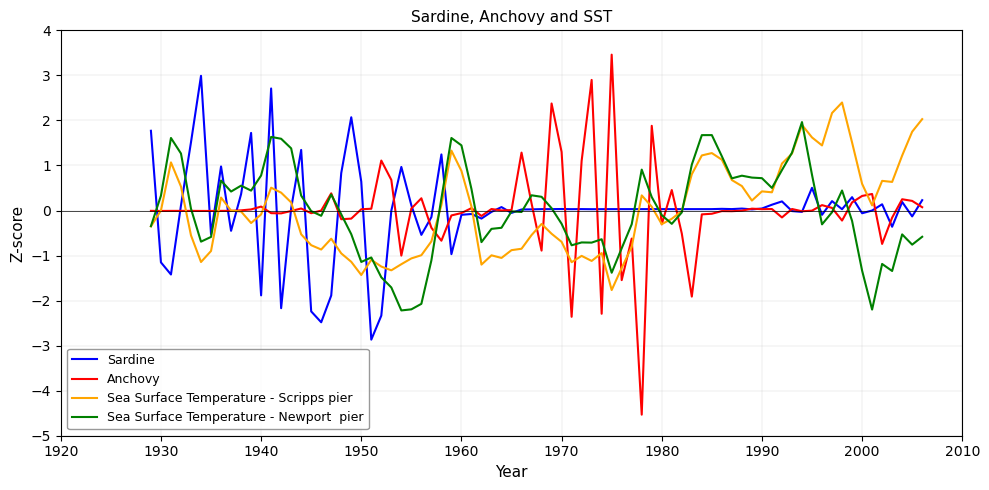

In [22]:
# Time graph with sea surface temperatures

years   = df_eco.index.year.values
sardine = df_eco['sardine'].values
anchovy = df_eco['anchovy'].values
sst_s   = df_eco['sio_sst'].values 
sst_n = df_eco['np_sst'].values

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(years, sardine, color='blue',   linewidth=1.5, label='Sardine')
ax.plot(years, anchovy, color='red',    linewidth=1.5, label='Anchovy')
ax.plot(years, sst_s,     color='orange', linewidth=1.5, label='Sea Surface Temperature - Scripps pier')
ax.plot(years, sst_n,     color='g', linewidth=1.5, label='Sea Surface Temperature - Newport  pier')

ax.axhline(0, color='black', linewidth=0.5, linestyle='-')  # horizontal line at 0
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Z-score', fontsize=11)
ax.set_xlim(1920, 2010)
ax.set_ylim(-5, 4)
ax.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='gray', fontsize=9)
ax.grid(True, linewidth=0.3, alpha=0.5)

ax.set_title('Sardine, Anchovy and SST', fontsize=11)
fig.tight_layout()
plt.show()

--- 
**Correlation Matrix**
While this initial correlation matrix was not in the original paper we attempted to create one in odrer to clearly show this relation is not a standard linear one. Simple increase in anchovy population does not equal simple increase in sardines as it is often the case in natural ecosystems. 

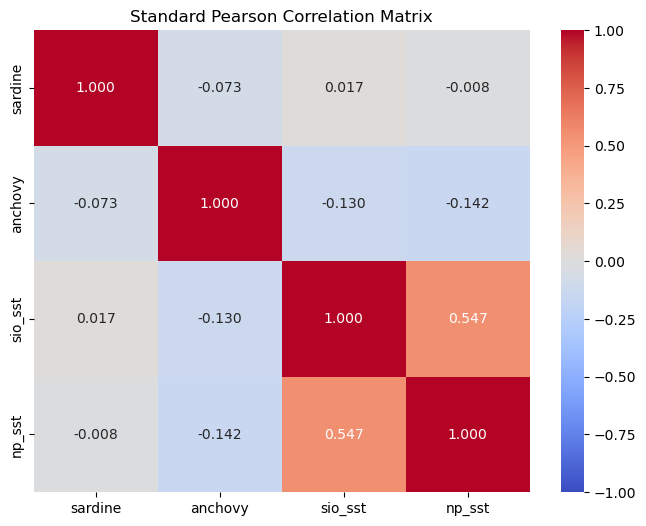

Standard Sardine & Anchovy Pearson r: -0.073


In [23]:
# Correlation matrix

corr_matrix = df_eco_normalized[['sardine', 'anchovy', 'sio_sst', 'np_sst']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f")
plt.title("Standard Pearson Correlation Matrix")
plt.show()

print(f"Standard Sardine & Anchovy Pearson r: {pearsonr(sardine, anchovy)[0]:.3f}")

In [25]:
# Figure 5E, 5D, 5F

E_eco = 3
tau_eco = 1
L_range_eco = np.arange(10, 75, 3)   # up to ~96% of N

print("Running CCM on empirical data (this may take a moment)...")

# Fig 5D: Sardine vs Anchovy 
_, rho_sard_xmap_anch = ccm_smooth(sardine, anchovy, E_eco, tau_eco, L_range_eco, num_samples=500)
_, rho_anch_xmap_sard = ccm_smooth(anchovy, sardine, E_eco, tau_eco, L_range_eco, num_samples=500)

# Fig 5E: SST (Scripps) vs Sardine
_, rho_sard_xmap_sst = ccm_smooth(sardine, sst_scripps, E_eco, tau_eco, L_range_eco, num_samples=500)
_, rho_sst_xmap_sard = ccm_smooth(sst_scripps, sardine, E_eco, tau_eco, L_range_eco, num_samples=500)

# Fig 5F: SST (Newport) vs Anchovy
_, rho_anch_xmap_sst = ccm_smooth(anchovy, sst_newport, E_eco, tau_eco, L_range_eco, num_samples=500)
_, rho_sst_xmap_anch = ccm_smooth(sst_newport, anchovy, E_eco, tau_eco, L_range_eco, num_samples=500)

# ADDED FIGURES : SST Scripps vs SST Newtport 
_, rho_ssts_xmap_sstnp = ccm_smooth(sst_scripps, sst_newport, E_eco, tau_eco, L_range_eco, num_samples=500)
_, rho_sstnp_xmap_ssts = ccm_smooth(sst_newport, sst_scripps, E_eco, tau_eco, L_range_eco, num_samples=500)


# ADDED FIGURES : SST Scripps vs SST Anchovy 
# Re-run only the new cross-pairings with the correct range
_, rho_ssts_xmap_anchovy  = ccm_smooth(sst_scripps, anchovy,    E_eco, tau_eco, L_range_eco, num_samples=500)
_, rho_anchovy_xmap_ssts  = ccm_smooth(anchovy,    sst_scripps, E_eco, tau_eco, L_range_eco, num_samples=500)
_, rho_sstnp_xmap_sardine = ccm_smooth(sst_newport, sardine,    E_eco, tau_eco, L_range_eco, num_samples=500)
_, rho_sardine_xmap_sstnp = ccm_smooth(sardine,    sst_newport, E_eco, tau_eco, L_range_eco, num_samples=500)


print("Done.") 

Running CCM on empirical data (this may take a moment)...
Done.


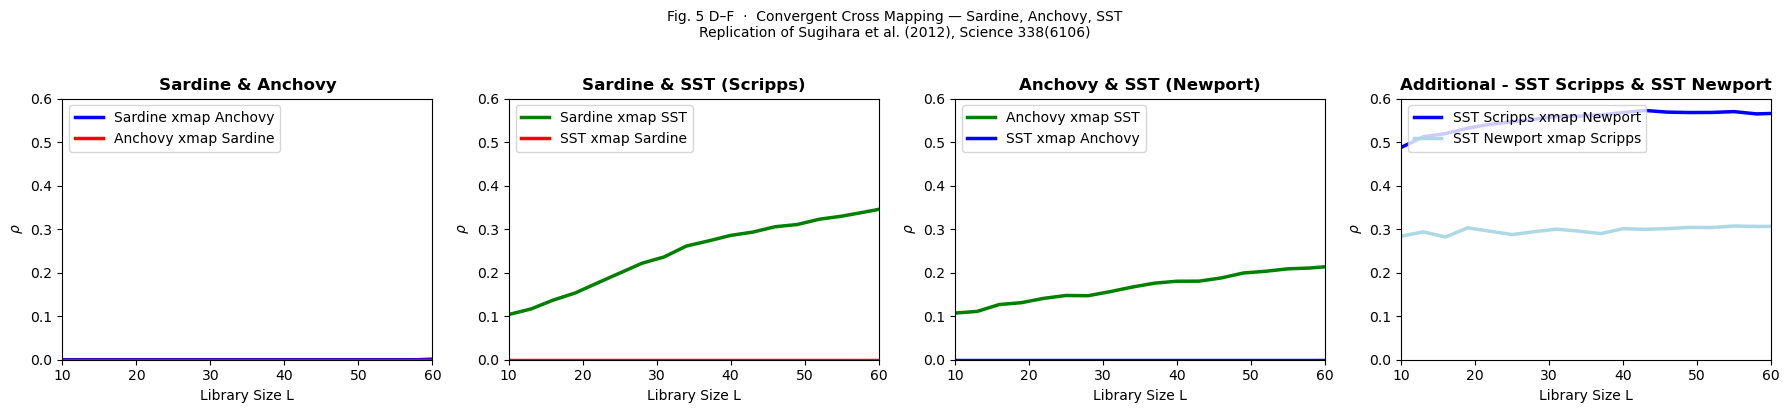


Conclusion:
CCM demonstrates no convergent cross mapping between Sardine and Anchovy.
However, both species show convergence when mapped against their respective SST records, proving they are driven by temperature.


In [26]:
# Plotting the Synthesis
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Panel D
axes[0].plot(L_range_eco, rho_sard_xmap_anch, 'b', linewidth=2.5, label='Sardine xmap Anchovy')
axes[0].plot(L_range_eco, rho_anch_xmap_sard, 'r', linewidth=2.5, label='Anchovy xmap Sardine')
axes[0].set_title('Sardine & Anchovy', fontweight='bold')

# Panel E
axes[1].plot(L_range_eco, rho_sard_xmap_sst, 'g', linewidth=2.5, label='Sardine xmap SST')
axes[1].plot(L_range_eco, rho_sst_xmap_sard, 'r', linewidth=2.5, label='SST xmap Sardine')
axes[1].set_title('Sardine & SST (Scripps)', fontweight='bold')

# Panel F
axes[2].plot(L_range_eco, rho_anch_xmap_sst, 'g', linewidth=2.5, label='Anchovy xmap SST')
axes[2].plot(L_range_eco, rho_sst_xmap_anch, 'b', linewidth=2.5, label='SST xmap Anchovy')
axes[2].set_title('Anchovy & SST (Newport)', fontweight='bold')

# Added Panel 
axes[3].plot(L_range_eco, rho_ssts_xmap_sstnp, 'blue', linewidth=2.5, label='SST Scripps xmap Newport')
axes[3].plot(L_range_eco, rho_sstnp_xmap_ssts, 'lightblue', linewidth=2.5, label='SST Newport xmap Scripps')
axes[3].set_title('Additional - SST Scripps & SST Newport', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Library Size L')
    ax.set_ylabel(r'$\rho$')
    ax.set_ylim(0, 0.6)
    ax.set_xlim(10, 60)
    ax.legend(loc='upper left')

fig.suptitle('Fig. 5 D–F  ·  Convergent Cross Mapping — Sardine, Anchovy, SST\n'
             'Replication of Sugihara et al. (2012), Science 338(6106)',
             fontsize=10, y=1.02)

plt.tight_layout()
plt.show()

print("\nConclusion:")
print("CCM demonstrates no convergent cross mapping between Sardine and Anchovy.")
print("However, both species show convergence when mapped against their respective SST records, proving they are driven by temperature.")

In [34]:
# Computation of rho values

# Suppress warnings for flat lines that don't fit an exponential curve well
warnings.filterwarnings('ignore', category=OptimizeWarning)

print("--- Asymptotic Convergence Analysis (L -> \u221E) ---\n")

# Apply curve fitting to Panel: Sardine & Anchovy
print(" Sardine & Anchovy")
fit_and_report(L_range_eco, rho_sard_xmap_anch, "Sardine xmap Anchovy")
fit_and_report(L_range_eco, rho_anch_xmap_sard, "Anchovy xmap Sardine")

# Apply curve fitting to Panel: Sardine & SST
print(" Sardine & SST (Scripps)")
fit_and_report(L_range_eco, rho_sard_xmap_sst, "Sardine xmap SST Scripps")
fit_and_report(L_range_eco, rho_sst_xmap_sard, "SST Scripps xmap Sardine")

# Apply curve fitting to Panel: Anchovy & SST
print(" Anchovy & SST (Newport)")
fit_and_report(L_range_eco, rho_anch_xmap_sst, "Anchovy xmap SST Newport")
fit_and_report(L_range_eco, rho_sst_xmap_anch, "SST Newport xmap Anchovy")

# Apply curve fitting to Added Panel: SST Spatial Coupling
print("ADDED PANEL: SST vs SST")
fit_and_report(L_range_eco, rho_ssts_xmap_sstnp, "SST Scripps xmap SST Newport")
fit_and_report(L_range_eco, rho_sstnp_xmap_ssts, "SST Newport xmap SST Scripps")

--- Asymptotic Convergence Analysis (L -> ∞) ---

 Sardine & Anchovy
Sardine xmap Anchovy           | rho(L) =  -1.015 * e^(-0.001 * L) + 1.000
                               | Converges to (ρ_∞): 1.000

Anchovy xmap Sardine           | Fit suggests NO convergence (flat line).
 Sardine & SST (Scripps)
Sardine xmap SST Scripps       | rho(L) =  -0.462 * e^(-0.024 * L) + 0.455
                               | Converges to (ρ_∞): 0.455

SST Scripps xmap Sardine       | Fit suggests NO convergence (flat line).
 Anchovy & SST (Newport)
Anchovy xmap SST Newport       | rho(L) =  -0.195 * e^(-0.023 * L) + 0.259
                               | Converges to (ρ_∞): 0.259

SST Newport xmap Anchovy       | Fit suggests NO convergence (flat line).
ADDED PANEL: SST vs SST
SST Scripps xmap SST Newport   | rho(L) =  -0.224 * e^(-0.105 * L) + 0.565
                               | Converges to (ρ_∞): 0.565

SST Newport xmap SST Scripps   | rho(L) =  -0.061 * e^(-0.008 * L) + 0.343
                    

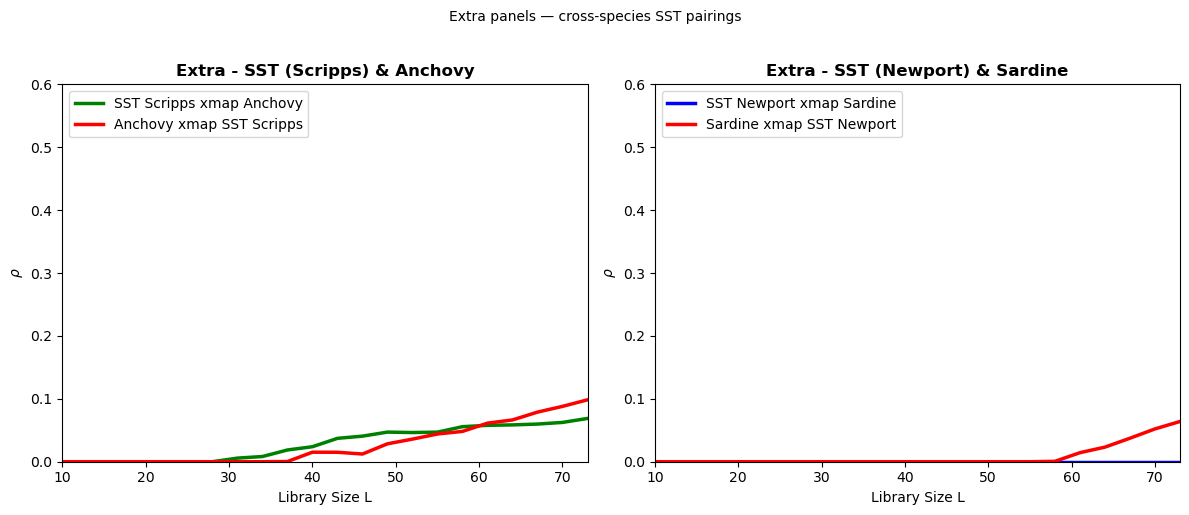

EXTRA: SST (Scripps) & Anchovy
  SST Scripps xmap Anchovy                                | ρ∞ = 1.000   (γ = 0.0013)
  Anchovy xmap SST Scripps                                | ρ∞ = 1.000   (γ = 0.0016)
EXTRA: SST (Newport) & Sardine
  SST Newport xmap Sardine                                | ➡  flat / no convergence
  Sardine xmap SST Newport                                | ρ∞ = 1.000   (γ = 0.0007)


np.float64(0.9999999999750284)

In [32]:
# ADDDED PANNELS
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel: SST (Scripps) & Anchovy  [cross-pairing]
axes[0].plot(L_range_eco, rho_ssts_xmap_anchovy, color='g',   linewidth=2.5, label='SST Scripps xmap Anchovy')
axes[0].plot(L_range_eco_full, rho_anchovy_xmap_ssts, color='r', linewidth=2.5, label='Anchovy xmap SST Scripps')
axes[0].set_title('Extra - SST (Scripps) & Anchovy', fontweight='bold')

# Panel: SST (Newport) & Sardine  [cross-pairing]
axes[1].plot(L_range_eco, rho_sstnp_xmap_sardine, color='b', linewidth=2.5, label='SST Newport xmap Sardine')
axes[1].plot(L_range_eco, rho_sardine_xmap_sstnp, color='r', linewidth=2.5, label='Sardine xmap SST Newport')
axes[1].set_title('Extra - SST (Newport) & Sardine', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Library Size L')
    ax.set_ylabel(r'$\rho$')
    ax.set_ylim(0, 0.6)
    ax.set_xlim(L_range_eco[0], L_range_eco[-1])  # matches the new range automatically
    ax.legend(loc='upper left')

fig.suptitle('Extra panels — cross-species SST pairings', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

print("EXTRA: SST (Scripps) & Anchovy")
fit_and_report(L_range_eco, rho_ssts_xmap_anchovy, "SST Scripps xmap Anchovy")
fit_and_report(L_range_eco, rho_anchovy_xmap_ssts, "Anchovy xmap SST Scripps")

print("EXTRA: SST (Newport) & Sardine")
fit_and_report(L_range_eco, rho_sstnp_xmap_sardine, "SST Newport xmap Sardine")
fit_and_report(L_range_eco, rho_sardine_xmap_sstnp, "Sardine xmap SST Newport")

---
**Calculating rho values when L tends towards infinity with curve fitting**